In [28]:
import pandas as pd

df = pd.read_csv('data/surveyDataSience.csv', skiprows=1, low_memory=False)

In [29]:
print("1. Numarul de respondenti: ", len(df))
print("2. Numarul de atribute: ", df.shape[1])
print("3. Numar respondenti cu date complete: ", df.dropna().shape[0])

edu_col = "What is the highest level of formal education that you have attained or plan to attain within the next 2 years?"
country_col = "In which country do you currently reside?"
gender_col = "What is your gender? - Selected Choice"
edu_years_map = {
    "No formal education past high school": 0.0,
    "Some college/university study without earning a bachelor’s degree": 1.5, 
    "Bachelor’s degree": 3.0,
    "Master’s degree": 5.0,           
    "Doctoral degree": 8.0,           
    "Professional doctorate": 8.0,     
    "I prefer not to answer": pd.NA
}
df['study_years'] = df[edu_col].map(edu_years_map)
print("4.Durata medie a anilor de studii superioare: ", df['study_years'].mean())
print("Durata medie a anilor de studii superioare (Romania): ", df[df[country_col] == "Romania"]["study_years"].mean())
print("Durata medie a anilor de studii superioare (femei din Romania): ", df[(df[country_col] == "Romania") & (df[gender_col] == "Woman")]["study_years"].mean())
print("5. Numar respondenti (femei din Romania) cu date complete: ", df[(df[country_col] == "Romania") & (df[gender_col] == "Woman")].dropna().shape[0])

1. Numarul de respondenti:  25973
2. Numarul de atribute:  369
3. Numar respondenti cu date complete:  0
4.Durata medie a anilor de studii superioare:  4.269845340487651
Durata medie a anilor de studii superioare (Romania):  4.758333333333334
Durata medie a anilor de studii superioare (femei din Romania):  5.34375
5. Numar respondenti (femei din Romania) cu date complete:  0


In [30]:
python_col = "What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python"
python_womans_ro = df[(df[python_col]).notna() & (df[gender_col] == 'Woman') & (df[country_col] == "Romania")]
print("6. Numar respondenti (femei din Romania) care programeaza cu Python: ", python_womans_ro.shape[0])

age_counts_python = python_womans_ro['What is your age (# years)?'].value_counts()
top_interval_python_count = age_counts_python.max()
top_intervals_python = age_counts_python[age_counts_python == top_interval_python_count]
print("Intervalul cel mai popular:\n", top_intervals_python.to_string(header = False))

cpp_col = "What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - C++"
cpp_womans_ro = df[(df[cpp_col].notna()) & (df[gender_col] == 'Woman') & (df[country_col] == "Romania")]
print("Numar respondenti (femei din Romania) care programeaza cu C++: ", cpp_womans_ro.shape[0])
age_counts_cpp = cpp_womans_ro['What is your age (# years)?'].value_counts()
top_interval_cpp_count = age_counts_cpp.max()
top_intervals_cpp = age_counts_cpp[age_counts_cpp == top_interval_cpp_count]
print("Intervalul cel mai popular:\n", top_intervals_cpp.to_string(header = False))

6. Numar respondenti (femei din Romania) care programeaza cu Python:  12
Intervalul cel mai popular:
 35-39    5
Numar respondenti (femei din Romania) care programeaza cu C++:  4
Intervalul cel mai popular:
 18-21    1
25-29    1
22-24    1
35-39    1


In [31]:
print("7.")
for col in df.columns:
    s = df[col].dropna() 

    s_num = pd.to_numeric(s, errors="coerce")

    is_numeric_col = len(s) > 0 and s_num.notna().all()

    print(f"\nColoana: {col}")

    if is_numeric_col:
        print(f"  Min: {s_num.min()}")
        print(f"  Max: {s_num.max()}")
    else:
        print(f"  Nr. valori posibile (distincte): {df[col].nunique(dropna=True)}")
    

7.

Coloana: Duration (in seconds)
  Min: 120
  Max: 2488653

Coloana: What is your age (# years)?
  Nr. valori posibile (distincte): 11

Coloana: What is your gender? - Selected Choice
  Nr. valori posibile (distincte): 5

Coloana: In which country do you currently reside?
  Nr. valori posibile (distincte): 66

Coloana: What is the highest level of formal education that you have attained or plan to attain within the next 2 years?
  Nr. valori posibile (distincte): 7

Coloana: Select the title most similar to your current role (or most recent title if retired): - Selected Choice
  Nr. valori posibile (distincte): 15

Coloana: For how many years have you been writing code and/or programming?
  Nr. valori posibile (distincte): 7

Coloana: What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python
  Nr. valori posibile (distincte): 1

Coloana: What programming languages do you use on a regular basis? (Select all that apply) - Selected Choi

In [32]:
experience_col = "For how many years have you been writing code and/or programming?"
exp_map = {
    "I have never written code": 0.0,
    "< 1 years": 0.5,
    "1-3 years": 2.0,
    "3-5 years": 4.0,
    "5-10 years": 7.5,
    "10-20 years": 15.0,
    "20+ years": 25.0
}

exp_years = df[experience_col].map(exp_map).dropna()
print("Minim:", exp_years.min())
print("Maxim:", exp_years.max())
print("Media:", exp_years.mean())
print("Deviatia standard:", exp_years.std())
print("Mediana:", exp_years.median())

Minim: 0.0
Maxim: 25.0
Media: 5.281061101913526
Deviatia standard: 6.79090316922895
Mediana: 2.0


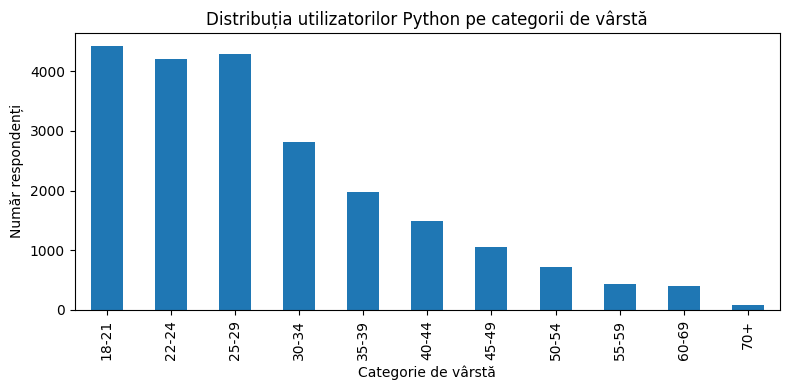

In [33]:
import matplotlib.pyplot as plt

python_users = df[df[python_col].notna()]
age_dist_counts = python_users['What is your age (# years)?'].value_counts().sort_index()
age_dist_counts.plot(kind="bar", figsize=(8,4), title="Distribuția utilizatorilor Python pe categorii de vârstă")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr respondenți")
plt.tight_layout()
plt.show()

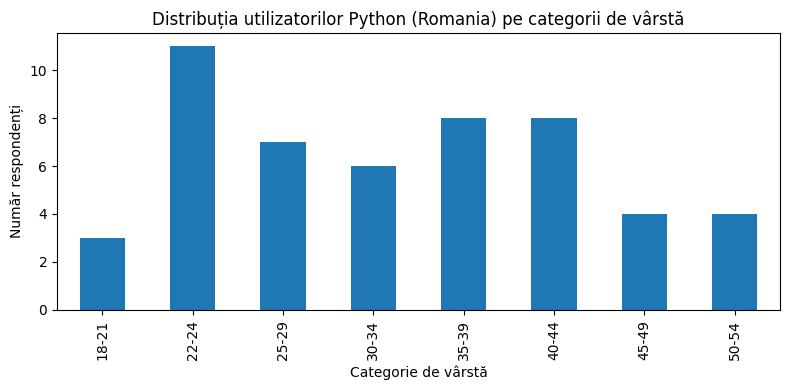

In [34]:
python_users_romania = df[(df[python_col].notna()) & (df[country_col] == "Romania")]
age_dist_counts = python_users_romania['What is your age (# years)?'].value_counts().sort_index()
age_dist_counts.plot(kind="bar", figsize=(8,4), title="Distribuția utilizatorilor Python (Romania) pe categorii de vârstă")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr respondenți")
plt.tight_layout()
plt.show()

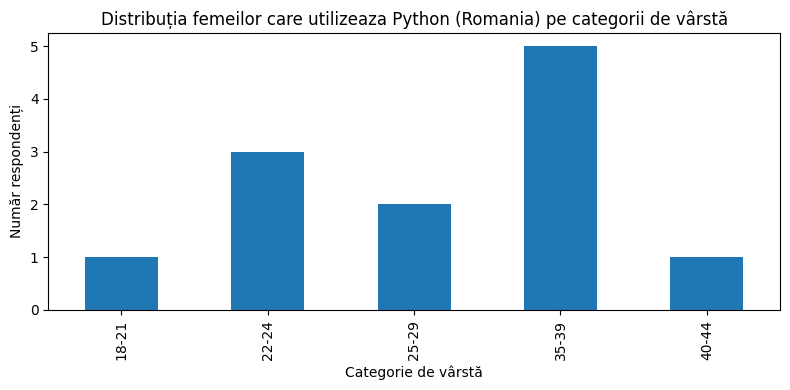

In [35]:
woman_python_users_romania = df[(df[python_col].notna()) & (df[country_col] == "Romania") & (df[gender_col] == "Woman")]
age_dist_counts = woman_python_users_romania['What is your age (# years)?'].value_counts().sort_index()
age_dist_counts.plot(kind="bar", figsize=(8,4), title="Distribuția femeilor care utilizeaza Python (Romania) pe categorii de vârstă")
plt.xlabel("Categorie de vârstă")
plt.ylabel("Număr respondenți")
plt.tight_layout()
plt.show()

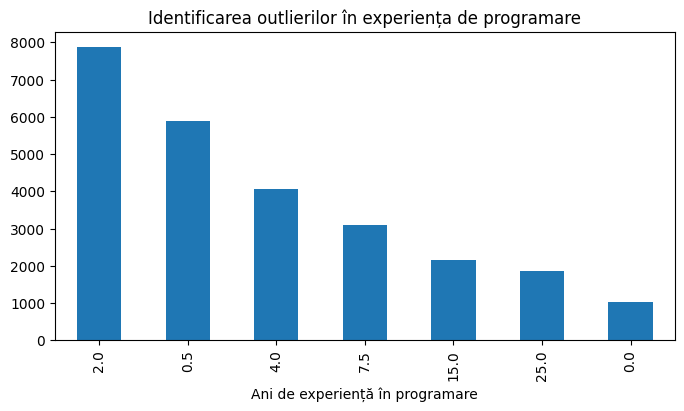

In [36]:
exp_years.value_counts().plot(kind="bar", figsize=(8,4))
plt.xlabel("Ani de experiență în programare")
plt.title("Identificarea outlierilor în experiența de programare")
plt.show()

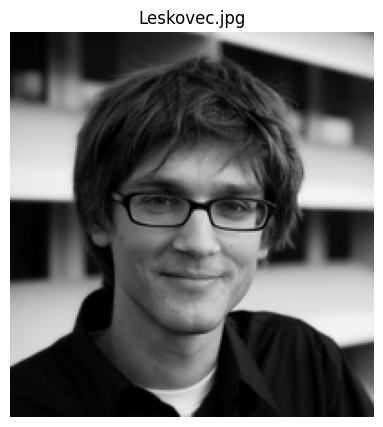

In [ ]:
from PIL import Image
from pathlib import Path
import random
import math

    folder = Path("data/images")
    file_names = [f.name for f in folder.iterdir() if f.is_file()]

img = Image.open(folder / random.choice(file_names))
#img.show()

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.title(Path(img.filename).name)
plt.show()

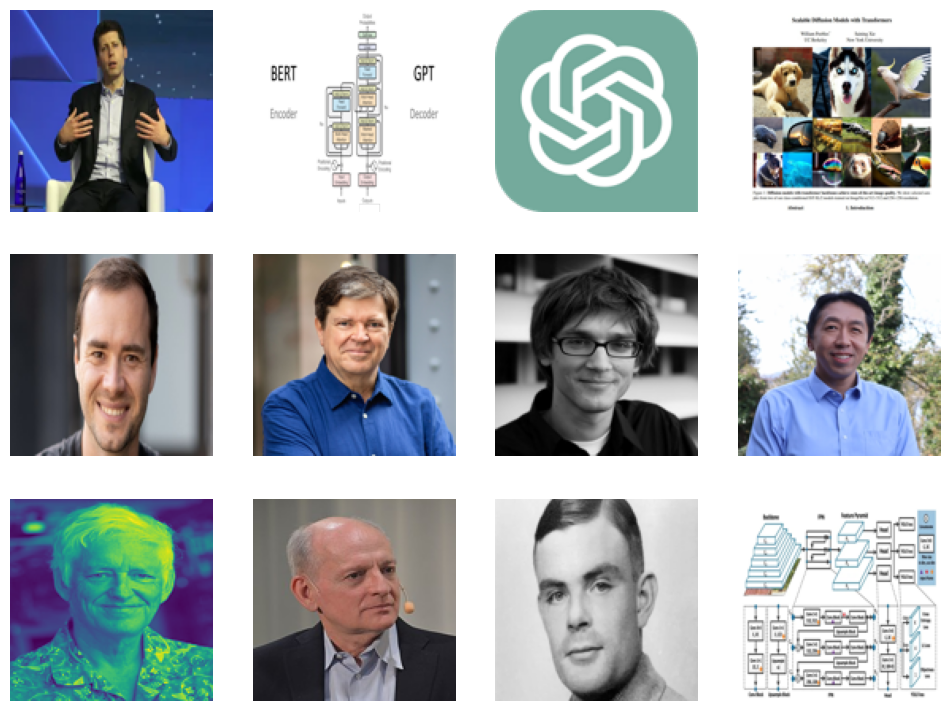

In [38]:
same_size = True
for file in file_names:
    full_path = folder / file
    width, height = Image.open(full_path).size

    if width != img.width and height != img.height:
        same_size = False

resized_images = []
for file in file_names:
    full_path = folder / file
    img = Image.open(full_path)

    if same_size:
        resized_images.append(img)
    else:
        width, height = img.size
        resized_img = img.resize((128, 128))
        resized_images.append(resized_img)

n = len(resized_images)
cols = 4                         
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

if rows == 1 and cols == 1:
    axes = [axes]
elif rows == 1 or cols == 1:
    axes = list(axes)
else:
    axes = axes.flatten()

for i, img in enumerate(resized_images):
    axes[i].imshow(img)
    axes[i].axis("off")

plt.show()
    

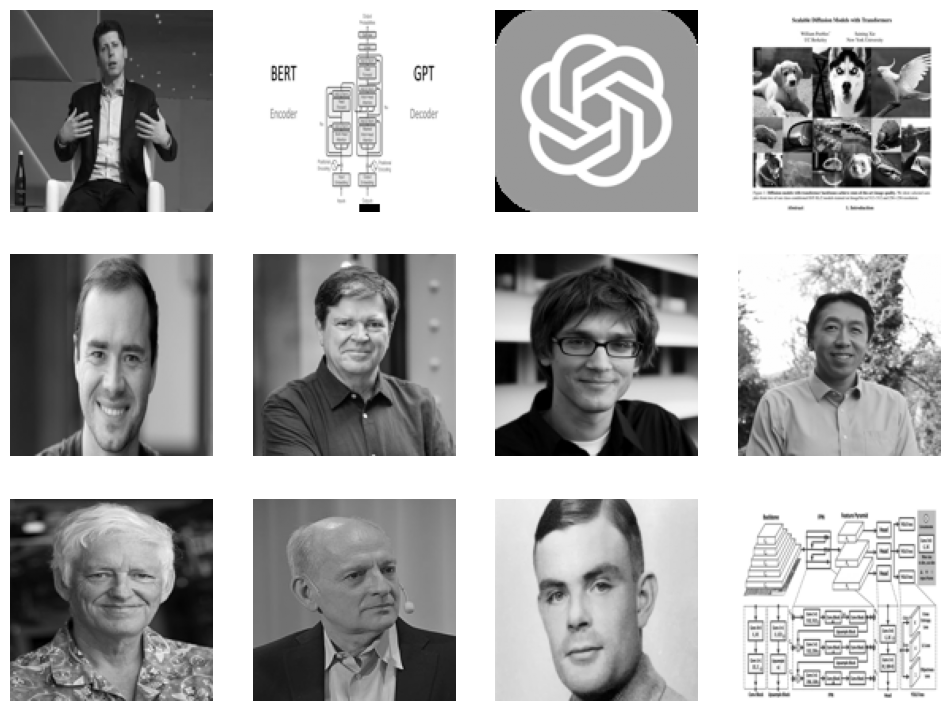

In [39]:
gray_images = [img.convert("L") for img in resized_images]

n = len(gray_images)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

if rows == 1 and cols == 1:
    axes = [axes]
elif rows == 1 or cols == 1:
    axes = list(axes)
else:
    axes = axes.flatten()

for i, gimg in enumerate(gray_images):
    axes[i].imshow(gimg, cmap="gray", vmin=0, vmax=255)
    axes[i].axis("off")

plt.show()

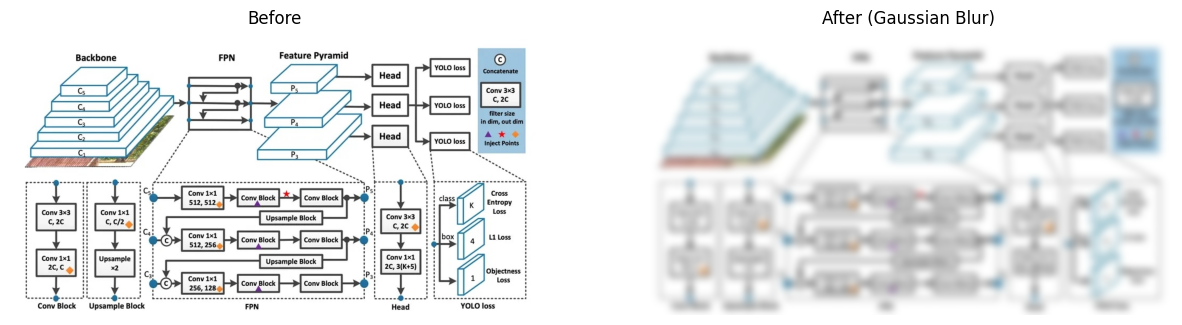

In [40]:
from PIL import ImageFilter

img_path = Path("data/images/YOLO.jpg")
img_before = Image.open(img_path)

img_after = img_before.filter(ImageFilter.GaussianBlur(radius=7))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(img_before)
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(img_after)
axes[1].set_title("After (Gaussian Blur)")
axes[1].axis("off")

plt.show()

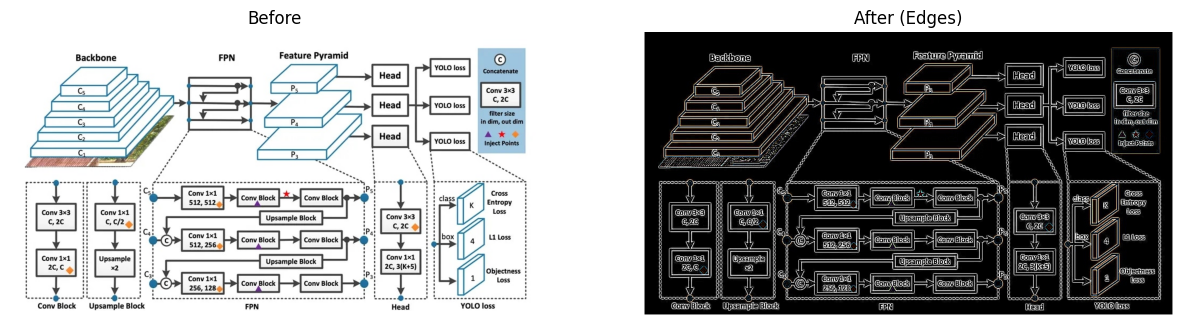

In [41]:
img_path = Path("data/images/YOLO.jpg")
img_before = Image.open(img_path)

img_edges = img_before.filter(ImageFilter.FIND_EDGES)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(img_before)
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(img_edges, cmap="gray")
axes[1].set_title("After (Edges)")
axes[1].axis("off")

plt.show()

In [42]:
import nltk
from nltk.tokenize import sent_tokenize, ToktokTokenizer
import unicodedata
from nltk.corpus import wordnet as wn

text_path = Path("data/texts.txt")
text = text_path.read_text(encoding="utf-8")

propozitii = sent_tokenize(text, language="english")
nr_propozitii = len(propozitii)

print("Numarul de propozitii:", nr_propozitii)

tokenizer = ToktokTokenizer()
tokens = tokenizer.tokenize(text)

cuvinte = [t for t in tokens if any(ch.isalpha() for ch in t)]
cuvinte_distincte = set(c.lower() for c in cuvinte)

# Metoda II (cuvinte distincte)
# from nltk import FreqDist
# cuvinte_norm = [c.lower() for c in cuvinte]
# frecvente = FreqDist(cuvinte_norm)
# print(len(frecvente))

print("Numarul de cuvinte:", len(cuvinte))
print("Numarul de cuvinte distincte:", len(cuvinte_distincte))

lungimi = [len(c) for c in cuvinte_distincte]
min_len = min(lungimi)
max_len = max(lungimi)

cele_mai_scurte = sorted(set(c for c in cuvinte_distincte if len(c) == min_len))
cele_mai_lungi = sorted(set(c for c in cuvinte_distincte if len(c) == max_len))

print(f"Lungime minima: {min_len}")
print("Cel mai scurt cuvant/cuvinte:", cele_mai_scurte)

print(f"Lungime maxima: {max_len}")
print("Cel mai lung cuvant/cuvinte:", cele_mai_lungi)

text_fara_diacritice = "".join(
    ch for ch in unicodedata.normalize("NFD", text)
    if unicodedata.category(ch) != "Mn"
)

# Exemplu unicode
# s = "Știință !"
# nfd = unicodedata.normalize("NFD", s)

# print("Original:", s)
# print("NFD chars:")
# for ch in nfd:
#     print(repr(ch), unicodedata.name(ch, "UNKNOWN"), unicodedata.category(ch))

print(text_fara_diacritice)

import re
def normalize_repetitii(s: str) -> str:
    # daca un caracter apare de 4+ ori consecutiv, il reduce la 1
    return re.sub(r'(.)\1{3,}', r'\1', s)

for cuv in cele_mai_lungi:
    cuv = normalize_repetitii(cuv)
    sinonime = set()
    for syn in wn.synsets(cuv, lang="ron"):
        for lemma in syn.lemmas("ron"):
            sinonime.add(lemma.name().replace("_", " "))

    sinonime.discard(cuv)
    print(f"\n{cuv} -> {sorted(sinonime) if sinonime else 'fara sinonime gasite'}")

Numarul de propozitii: 10
Numarul de cuvinte: 159
Numarul de cuvinte distincte: 93
Lungime minima: 1
Cel mai scurt cuvant/cuvinte: ['e', 'o']
Lungime maxima: 34
Cel mai lung cuvant/cuvinte: ['confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm']
Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam s

In [43]:
# Alternativa pentru NLTK la ultimul subpunct cu sinonime: 
# https://github.com/dumitrescustefan/RoWordNet
# Data + API pentru python (gasit pe google cautand alternative) facut de un roman. 
import rowordnet as rwn
wn = rwn.RoWordNet()

word = 'frumos'
synset_ids = wn.synsets(literal=word)

for synset_id in synset_ids:
    synset_object = wn.synset(synset_id)
    synset_object = wn(synset_id)
    print("Sinonime: {}".format(synset_object.literals))
    print("Ex: {}".format(synset_object.definition))

Sinonime: ['frumos']
Ex: plăcut, armonios, estetic.
Sinonime: ['frumos']
Ex: Expresie: A fi frumos (din partea cuiva) = a se cuveni, a fi cuviincios; a fi lăudabil
Sinonime: ['frumos']
Ex: feminin și atrăgător
Sinonime: ['frumos_mirositor', 'odorant', 'odorifer']
Ex: Care răspândește un miros plăcut
Sinonime: ['agreabil', 'drăguț', 'estetic', 'frumos', 'plăcut']
Ex: De o manieră plăcută ochiului
Sinonime: ['frumos']
Ex: În mod plăcut, armonios, estetic
Sinonime: ['frumos']
Ex: De o manieră frumoasă
Sinonime: ['frumos']
Ex: care privește frumosul, care corespunde cerințelor esteticii
Sinonime: ['[se] comporta_frumos', '[se] purta_frumos']
Ex: A avea o conduită manierată
Sinonime: ['[se] comporta_frumos', '[se] purta_frumos']
Ex: A avea o conduită manierată
Sinonime: ['frumos']
Ex: (Despre timp) Senin, calm ( din punctul de vedere al stării atmosferice).
Sinonime: ['frumos']
Ex: Care place pentru armonia liniilor, mișcărilor, culorilor etc.


In [44]:
# Min-max

min_val = df["study_years"].min()
max_val = df["study_years"].max()

df["study_years_minmax"] = (df["study_years"] - min_val) / (max_val - min_val)

print(df[["study_years", "study_years_minmax"]].dropna().head(10))

   study_years study_years_minmax
0          3.0              0.375
1          5.0              0.625
2          5.0              0.625
3          8.0                1.0
4          8.0                1.0
6          1.5             0.1875
7          3.0              0.375
8          3.0              0.375
10         8.0                1.0
11         5.0              0.625


In [45]:
# Clipping

exp_years_clipped = exp_years.clip(upper=15.0)

print(exp_years.value_counts().sort_index())

print("\nFrecvente dupa:")
print(exp_years_clipped.value_counts().sort_index())

For how many years have you been writing code and/or programming?
0.0     1032
0.5     5881
2.0     7874
4.0     4061
7.5     3099
15.0    2166
25.0    1860
Name: count, dtype: int64

Frecvente dupa:
For how many years have you been writing code and/or programming?
0.0     1032
0.5     5881
2.0     7874
4.0     4061
7.5     3099
15.0    4026
Name: count, dtype: int64


In [46]:
import numpy as np

# Standardizare (normalizare Z)

images = []
for file in file_names:
    full_path = folder / file
    img = Image.open(full_path)
    images.append(img)

for img in images:
    pixels = np.array(img, dtype=np.float32)

    mu = pixels.mean()
    sigma = pixels.std() + 1e-8

    pixels_std = (pixels - mu) / sigma

    print(pixels_std)

[[[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 [[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 [[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 ...

 [[-0.40349928 -0.01705574  1.5132606 ]
  [-0.40349928 -0.01705574  1.5132606 ]
  [-0.40349928 -0.01705574  1.5132606 ]
  ...
  [-1.0063512  -0.7590273   0.7403736 ]
  [-1.0372666  -0.74356955  0.7403736 ]
  [-1.0527244  -0.7281118   0.7403736 ]]

 [

In [47]:
# Log scalling

from nltk import FreqDist
for i, propozitie in enumerate(propozitii, start=1):
    tokens = tokenizer.tokenize(propozitie)
    cuvinte = [t for t in tokens if any(ch.isalpha() for ch in t)]
    cuvinte_norm = [c.lower() for c in cuvinte]
    
    frecvente = FreqDist(cuvinte_norm)
    frecvente_log = {cuv: np.log1p(cnt) for cuv, cnt in frecvente.items()}

    print(f"\nPropozitia {i}:")
    for cuv, cnt in frecvente.most_common():
        print(f"{cuv}: count={cnt}, log_count={frecvente_log[cuv]:.4f}")
    


Propozitia 1:
de: count=2, log_count=1.0986
mesaj: count=1, log_count=0.6931
informare: count=1, log_count=0.6931
cursul: count=1, log_count=0.6931
și: count=1, log_count=0.6931
laboratoarele: count=1, log_count=0.6931
inteligență: count=1, log_count=0.6931
artificială: count=1, log_count=0.6931
vor: count=1, log_count=0.6931
fi: count=1, log_count=0.6931
o: count=1, log_count=0.6931
provocare: count=1, log_count=0.6931
pentru: count=1, log_count=0.6931
toți: count=1, log_count=0.6931

Propozitia 2:
suntem: count=1, log_count=0.6931
convinși: count=1, log_count=0.6931
că: count=1, log_count=0.6931
veți: count=1, log_count=0.6931
realiza: count=1, log_count=0.6931
proiecte: count=1, log_count=0.6931
foarte: count=1, log_count=0.6931
interesante: count=1, log_count=0.6931

Propozitia 3:
vă: count=1, log_count=0.6931
încurajăm: count=1, log_count=0.6931
să: count=1, log_count=0.6931
adresați: count=1, log_count=0.6931
întrebări: count=1, log_count=0.6931
atunci: count=1, log_count=0.6931